# Домашнее задание 2 по теме «Элементарные методы анализа временных рядов»

In [20]:
# импортирую библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error


Загрузка данных

In [21]:
# загружаю 2 ряда
airlines_passengers = pd.read_csv("international-airline-passengers.csv")
female_births = pd.read_csv("daily-total-female-births-in-cal.csv")

# привожу колонки к одному виду
airlines_passengers.columns = ["Date", "Count"]
female_births.columns = ["Date", "Count"]

# беру сами ряды
air_series = airlines_passengers["Count"]
births_series = female_births["Count"]


Смотрю на ряды

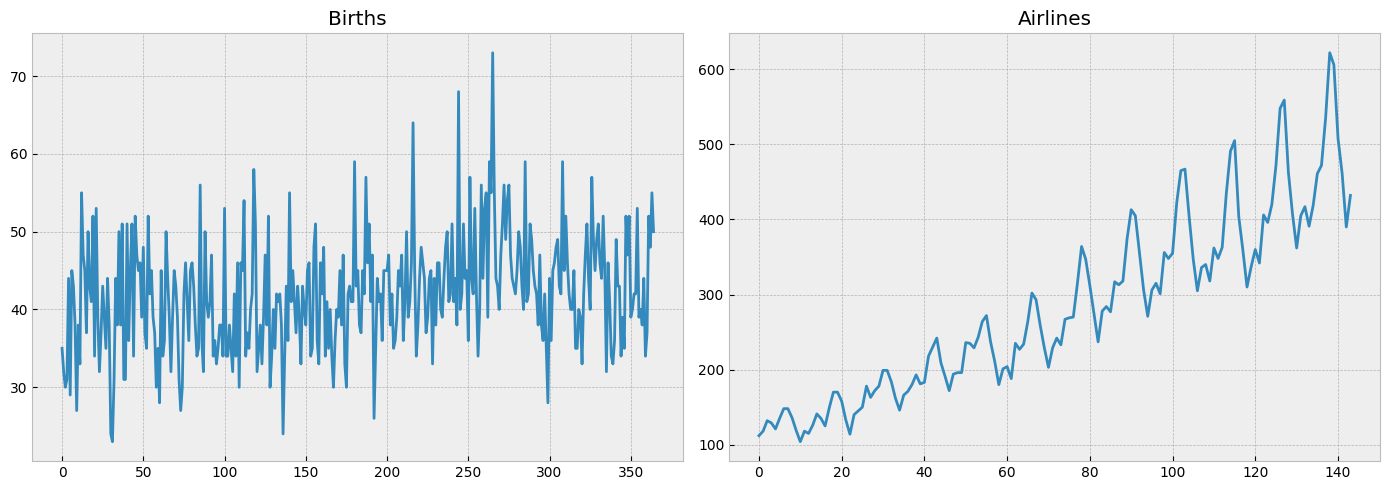

In [22]:
# строю графики рядов
with plt.style.context('bmh'):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(births_series)
    plt.title("Births")

    plt.subplot(1, 2, 2)
    plt.plot(air_series)
    plt.title("Airlines")

    plt.tight_layout()
    plt.show()


Проверяю стационарность

In [23]:
# функция для теста Дики-Фуллера
def adf_test(series, name=""):
    result = adfuller(series)
    print(name)
    print("stat:", result[0])
    print("p-value:", result[1])
    print("-" * 30)

# проверяю оба ряда
adf_test(births_series, "Births")
adf_test(air_series, "Airlines")


Births
stat: -4.808291253559765
p-value: 5.2434129901498554e-05
------------------------------
Airlines
stat: 0.8153688792060498
p-value: 0.991880243437641
------------------------------


По результатам теста:
- Births беру как стационарный ряд
- Airlines беру как нестационарный ряд

Функции


In [24]:
# скользящее среднее
def moving_average(series, n):
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    return series.rolling(n).mean()

# прогноз для MA
def predict(series, N, n_pred):
    new_series = series.copy()
    for _ in range(n_pred):
        next_val = new_series[-N:].mean()
        next_val_series = pd.Series([next_val])
        new_series = pd.concat([new_series, next_val_series], ignore_index=True)
    return new_series


In [25]:
# экспоненциальное сглаживание
def exponential_moving_average(series, alpha, n_pred=None):
    result = [series.iloc[0]]

    for n in range(1, len(series)):
        result.append(alpha * series.iloc[n-1] + (1 - alpha) * result[n-1])

    if not n_pred:
        return pd.Series(result)

    predictions = [alpha * series.iloc[-1] + (1 - alpha) * result[-1]]

    for _ in range(n_pred - 1):
        res = alpha * predictions[-1] + (1 - alpha) * result[-1]
        result.append(res)
        predictions.append(res)

    extended_series = pd.concat([series, pd.Series(predictions)], ignore_index=True)
    return extended_series, pd.Series(result)


In [26]:
# двойное экспоненциальное сглаживание
def double_ema_with_preds(series, alpha, beta, n_preds):
    result = [series.iloc[0]]
    level, trend = series.iloc[0], series.iloc[1] - series.iloc[0]

    for n in range(1, len(series)):
        value = series.iloc[n]
        last_level, level = level, alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
        result.append(level + trend)

    preds = []
    for n in range(n_preds):
        value = result[-1]
        last_level, level = level, alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
        result.append(level + trend)
        preds.append(level + trend)

    return pd.concat([series, pd.Series(preds)], ignore_index=True), pd.Series(result)


In [27]:
# вспомогательные функции для TEMA
def initial_trend(series, season_len):
    total = 0.0
    for i in range(season_len):
        total += float(series.iloc[i + season_len] - series.iloc[i]) / season_len
    return total / season_len

def initial_seasonal_components(series, slen):
    seasonals = {}
    season_averages = []
    n_seasons = int(len(series) / slen)

    for j in range(n_seasons):
        season_averages.append(sum(series.iloc[slen*j:slen*j+slen]) / float(slen))

    for i in range(slen):
        sum_of_vals_over_avg = 0.0
        for j in range(n_seasons):
            sum_of_vals_over_avg += series.iloc[slen*j+i] - season_averages[j]
        seasonals[i] = sum_of_vals_over_avg / n_seasons

    return seasonals

# тройное экспоненциальное сглаживание
def triple_exponential_smoothing(series, slen, alpha, beta, gamma, n_preds):
    result = []
    seasonals = initial_seasonal_components(series, slen)

    for i in range(len(series) + n_preds):
        if i == 0:
            smooth = series.iloc[0]
            trend = initial_trend(series, slen)
            result.append(series.iloc[0])
            continue

        if i >= len(series):
            m = i - len(series) + 1
            result.append((smooth + m * trend) + seasonals[i % slen])
        else:
            val = series.iloc[i]
            last_smooth, smooth = smooth, alpha * (val - seasonals[i % slen]) + (1 - alpha) * (smooth + trend)
            trend = beta * (smooth - last_smooth) + (1 - beta) * trend
            seasonals[i % slen] = gamma * (val - smooth) + (1 - gamma) * seasonals[i % slen]
            result.append(smooth + trend + seasonals[i % slen])

    return result


Разделение на train и test

In [28]:
# делю ряд на train и test
def train_test_split_ts(series, train_size=0.8):
    split = int(len(series) * train_size)
    train = series.iloc[:split].reset_index(drop=True)
    test = series.iloc[split:].reset_index(drop=True)
    return train, test

births_train, births_test = train_test_split_ts(births_series)
air_train, air_test = train_test_split_ts(air_series)

print("Births train:", len(births_train), "test:", len(births_test))
print("Airlines train:", len(air_train), "test:", len(air_test))


Births train: 292 test: 73
Airlines train: 115 test: 29


Подбор параметров

In [29]:
# подбираю параметры для всех моделей
def find_best_models(series, slen):
    results = []

    train, test = train_test_split_ts(series)

    windows = [3, 7, 12]
    alphas = [0.1, 0.3, 0.5]
    betas = [0.1, 0.3, 0.5]
    gammas = [0.1, 0.3, 0.5]

    for window in windows:
        pred = predict(train, window, len(test))
        forecast = pred.iloc[-len(test):].reset_index(drop=True)
        error = mean_squared_error(test, forecast)
        results.append(["MA", f"window={window}", error])

    for alpha in alphas:
        pred, _ = exponential_moving_average(train, alpha, len(test))
        forecast = pred.iloc[-len(test):].reset_index(drop=True)
        error = mean_squared_error(test, forecast)
        results.append(["EMA", f"alpha={alpha}", error])

    for alpha in alphas:
        for beta in betas:
            pred, _ = double_ema_with_preds(train, alpha, beta, len(test))
            forecast = pred.iloc[-len(test):].reset_index(drop=True)
            error = mean_squared_error(test, forecast)
            results.append(["DEMA", f"alpha={alpha}, beta={beta}", error])

    for alpha in alphas:
        for beta in betas:
            for gamma in gammas:
                pred = triple_exponential_smoothing(train, slen, alpha, beta, gamma, len(test))
                forecast = pd.Series(pred[-len(test):])
                error = mean_squared_error(test, forecast)
                results.append(["TEMA", f"alpha={alpha}, beta={beta}, gamma={gamma}", error])

    results_df = pd.DataFrame(results, columns=["Model", "Parameters", "MSE"])
    results_df = results_df.sort_values("MSE").reset_index(drop=True)
    return results_df


Эксперимент для стационарного ряда Births

In [30]:
# смотрю лучшие параметры
births_results = find_best_models(births_series, 12)
births_results.head(10)


,Model,Parameters,MSE
0,MA,window=3,44.060056
1,EMA,alpha=0.5,48.399521
2,MA,window=7,50.089607
3,MA,window=12,50.940477
4,TEMA,"alpha=0.3, beta=0.1, gamma=0.1",52.478481
5,EMA,alpha=0.3,52.504647
6,TEMA,"alpha=0.5, beta=0.1, gamma=0.1",52.999929
7,TEMA,"alpha=0.1, beta=0.3, gamma=0.5",53.566137
8,DEMA,"alpha=0.3, beta=0.3",57.225530
9,EMA,alpha=0.1,57.830802


In [31]:
# беру лучшую модель
births_best = births_results.iloc[0]
births_best


,0
Model,MA
Parameters,window=3
MSE,44.060056


Прогноз лучшей модели для Births

In [32]:
# строю прогноз по лучшей модели
if births_best["Model"] == "MA":
    window = int(births_best["Parameters"].split("=")[1])
    births_forecast = predict(births_train, window, len(births_test)).iloc[-len(births_test):].reset_index(drop=True)

elif births_best["Model"] == "EMA":
    alpha = float(births_best["Parameters"].split("=")[1])
    births_forecast, _ = exponential_moving_average(births_train, alpha, len(births_test))
    births_forecast = births_forecast.iloc[-len(births_test):].reset_index(drop=True)

elif births_best["Model"] == "DEMA":
    parts = births_best["Parameters"].replace("alpha=", "").replace(" beta=", "").split(",")
    alpha = float(parts[0])
    beta = float(parts[1].replace("beta=", "").strip())
    births_forecast, _ = double_ema_with_preds(births_train, alpha, beta, len(births_test))
    births_forecast = births_forecast.iloc[-len(births_test):].reset_index(drop=True)

else:
    parts = births_best["Parameters"].replace("alpha=", "").replace(" beta=", "").replace(" gamma=", "").split(",")
    alpha = float(parts[0])
    beta = float(parts[1].strip())
    gamma = float(parts[2].strip())
    births_forecast = pd.Series(triple_exponential_smoothing(births_train, 12, alpha, beta, gamma, len(births_test))[-len(births_test):])

births_test_mse = mean_squared_error(births_test, births_forecast)

print("Best model:", births_best["Model"])
print("Best parameters:", births_best["Parameters"])
print("Test MSE:", births_test_mse)


Best model: MA
Best parameters: window=3
Test MSE: 44.060055623582954


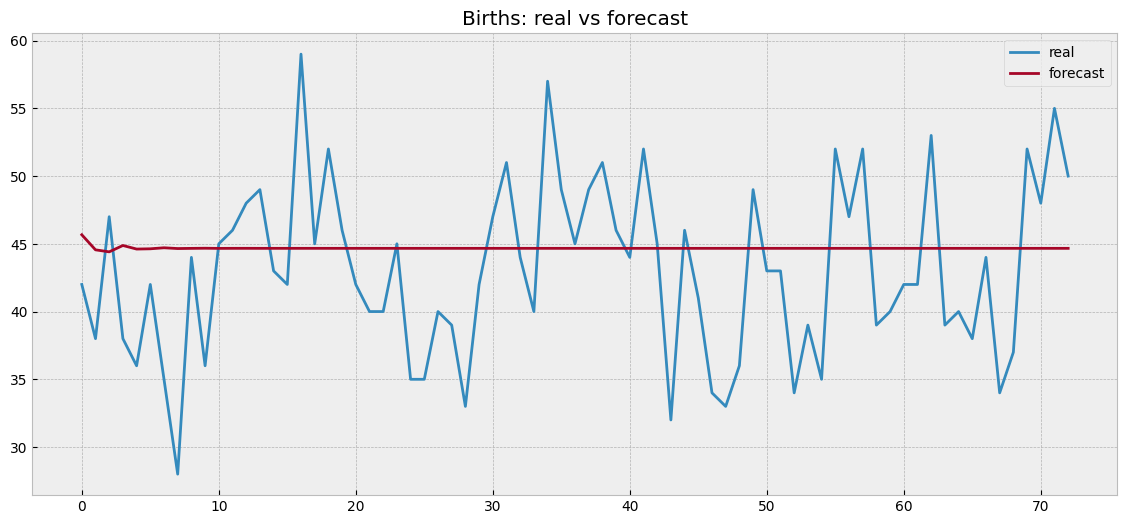

In [33]:
# сравниваю прогноз и реальные значения
with plt.style.context('bmh'):
    plt.figure(figsize=(14, 6))
    plt.plot(births_test.reset_index(drop=True), label='real')
    plt.plot(births_forecast.reset_index(drop=True), label='forecast')
    plt.title("Births: real vs forecast")
    plt.legend()
    plt.show()


Эксперимент для нестационарного ряда Airlines

In [34]:
# смотрю лучшие параметры
air_results = find_best_models(air_series, 12)
air_results.head(10)


,Model,Parameters,MSE
0,TEMA,"alpha=0.1, beta=0.1, gamma=0.5",1287.647878
1,TEMA,"alpha=0.1, beta=0.1, gamma=0.3",1392.452917
2,TEMA,"alpha=0.3, beta=0.3, gamma=0.3",1393.737464
3,TEMA,"alpha=0.3, beta=0.1, gamma=0.3",1564.233356
4,TEMA,"alpha=0.1, beta=0.1, gamma=0.1",1740.565636
5,TEMA,"alpha=0.3, beta=0.1, gamma=0.1",1760.680376
6,TEMA,"alpha=0.3, beta=0.1, gamma=0.5",2418.509219
7,TEMA,"alpha=0.5, beta=0.1, gamma=0.5",2722.865510
8,TEMA,"alpha=0.1, beta=0.3, gamma=0.1",3524.764782
9,TEMA,"alpha=0.1, beta=0.3, gamma=0.3",4553.230889


In [35]:
# беру лучшую модель
air_best = air_results.iloc[0]
air_best


,0
Model,TEMA
Parameters,"alpha=0.1, beta=0.1, gamma=0.5"
MSE,1287.647878


Прогноз лучшей модели для Airlines

In [36]:
# строю прогноз по лучшей модели
if air_best["Model"] == "MA":
    window = int(air_best["Parameters"].split("=")[1])
    air_forecast = predict(air_train, window, len(air_test)).iloc[-len(air_test):].reset_index(drop=True)

elif air_best["Model"] == "EMA":
    alpha = float(air_best["Parameters"].split("=")[1])
    air_forecast, _ = exponential_moving_average(air_train, alpha, len(air_test))
    air_forecast = air_forecast.iloc[-len(air_test):].reset_index(drop=True)

elif air_best["Model"] == "DEMA":
    parts = air_best["Parameters"].replace("alpha=", "").replace(" beta=", "").split(",")
    alpha = float(parts[0])
    beta = float(parts[1].replace("beta=", "").strip())
    air_forecast, _ = double_ema_with_preds(air_train, alpha, beta, len(air_test))
    air_forecast = air_forecast.iloc[-len(air_test):].reset_index(drop=True)

else:
    parts = air_best["Parameters"].replace("alpha=", "").replace(" beta=", "").replace(" gamma=", "").split(",")
    alpha = float(parts[0])
    beta = float(parts[1].strip())
    gamma = float(parts[2].strip())
    air_forecast = pd.Series(triple_exponential_smoothing(air_train, 12, alpha, beta, gamma, len(air_test))[-len(air_test):])

air_test_mse = mean_squared_error(air_test, air_forecast)

print("Best model:", air_best["Model"])
print("Best parameters:", air_best["Parameters"])
print("Test MSE:", air_test_mse)


Best model: TEMA
Best parameters: alpha=0.1, beta=0.1, gamma=0.5
Test MSE: 1287.6478776730773


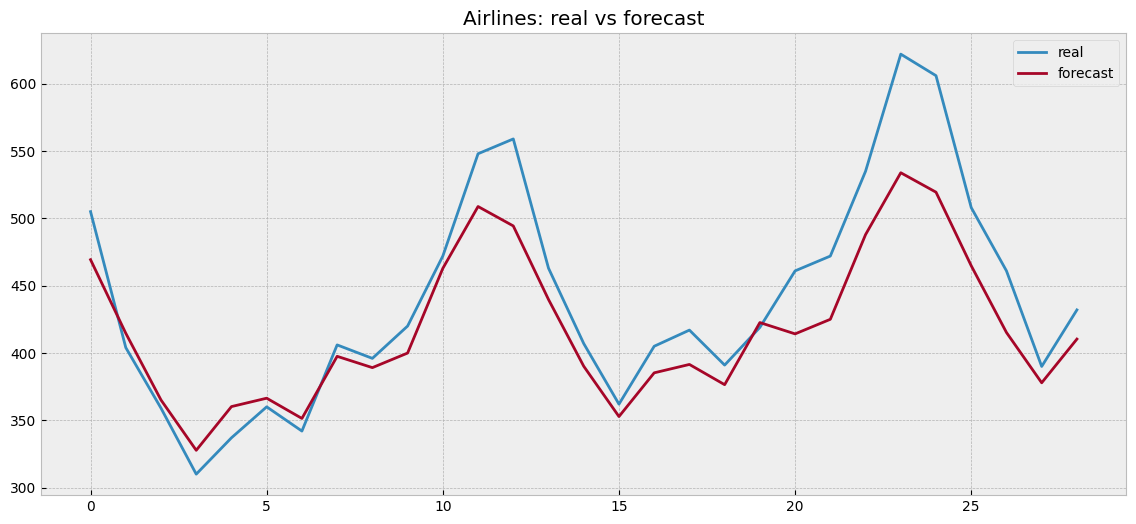

In [37]:
# сравниваю прогноз и реальные значения
with plt.style.context('bmh'):
    plt.figure(figsize=(14, 6))
    plt.plot(air_test.reset_index(drop=True), label='real')
    plt.plot(air_forecast.reset_index(drop=True), label='forecast')
    plt.title("Airlines: real vs forecast")
    plt.legend()
    plt.show()


Итоговая таблица

In [38]:
# собираю итог
summary = pd.DataFrame({
    "Series": ["Births", "Airlines"],
    "Best model": [births_best["Model"], air_best["Model"]],
    "Best parameters": [births_best["Parameters"], air_best["Parameters"]],
    "Test MSE": [births_test_mse, air_test_mse]
})

summary


,Series,Best model,Best parameters,Test MSE
0,Births,MA,window=3,44.060056
1,Airlines,TEMA,"alpha=0.1, beta=0.1, gamma=0.5",1287.647878


## Вывод

Провела эксперимент с моделями MA, EMA, DEMA и TEMA на двух рядах.

Для каждого ряда подобрала параметры на первой части ряда, потом сделала прогноз на последней части и сравнила результат по MSE.

Лучшую модель выбирала по минимальной ошибке.
